In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nOGUiSTbKGxLtUpsmE9d")
project = rf.workspace("melikeavan").project("rock-paper-scissors-ishcs")
version = project.version(1)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results

/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results


In [5]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.0/112.6 GB disk)


In [12]:
from ultralytics import YOLO

# Load a pretrained model (nano version for speed)
model = YOLO("yolov8n.pt")

In [13]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [14]:
# Fine-tune on your dataset
results = model.train(
    data="/content/Rock-Paper-Scissors-1/data.yaml",  # path to dataset YAML
    epochs=15,                 # number of epochs
    imgsz=640,                 # image size
    batch=16,                  # batch size

    project="/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results",     # where to save results
    name="exp1",               # experiment name
    device="0"                 # use GPU 0 (or "cpu")
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rock-Paper-Scissors-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

## Retraining the last weights for more performance

In [18]:
model = YOLO("/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/exp1/weights/best.pt")
# Fine-tune on your dataset
results = model.train(
    data="/content/Rock-Paper-Scissors-1/data.yaml",  # path to dataset YAML
    epochs=15,                 # number of epochs
    imgsz=640,                 # image size
    batch=16,                  # batch size
    project="/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection-20251024T084237Z-1-001/results",     # where to save results
    name="exp2",               # experiment name
    device="0"                 # use GPU 0 (or "cpu")
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rock-Paper-Scissors-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/exp1/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2, nbs=64

In [26]:
for key , value in results.results_dict.items():
  print(f"{key} : {value}")


metrics/precision(B) : 0.9548831903442393
metrics/recall(B) : 0.9384511257378212
metrics/mAP50(B) : 0.9618046673858021
metrics/mAP50-95(B) : 0.7778665154947412
fitness : 0.7778665154947412


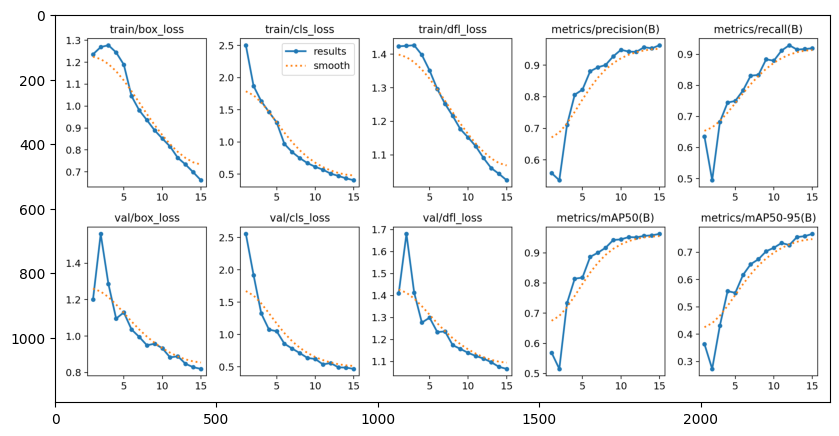

In [27]:
import matplotlib.pyplot as plt
img = plt.imread("/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/exp1/results.png")
plt.figure(figsize=(10,10))
plt.imshow(img)

In [29]:
img = plt.imread("/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/exp2/confusion_matrix.png")
plt.figure(figsize=(10,10))
plt.imshow(img)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/exp2/confusion_matrix.png'

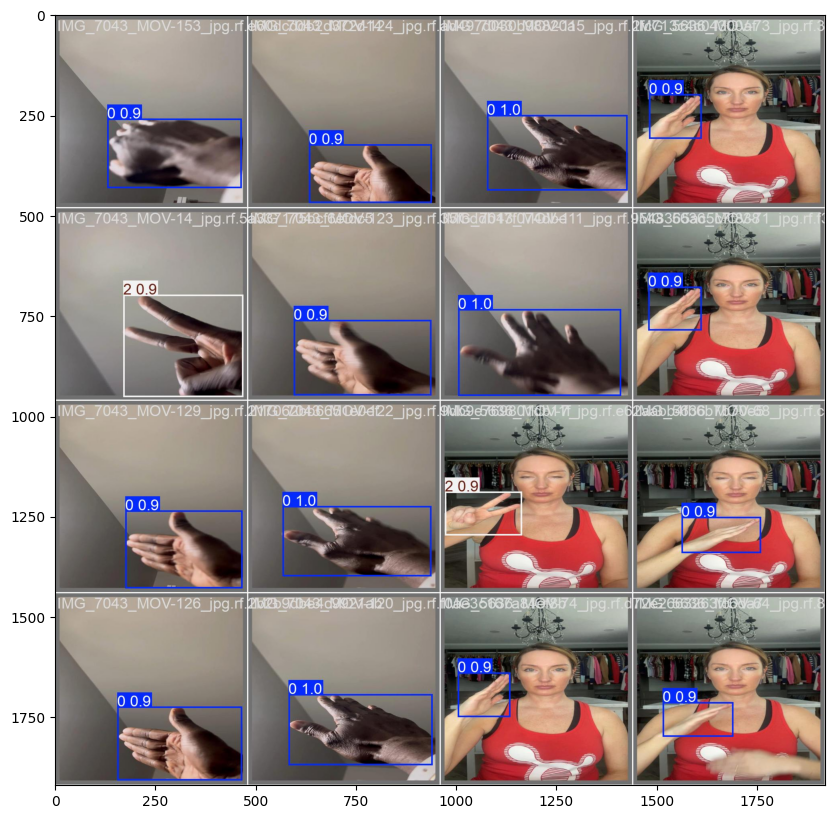

In [22]:
img = plt.imread("/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/exp1/val_batch1_pred.jpg")
plt.figure(figsize=(10,10))
plt.imshow(img)

In [23]:
# Validate the trained model
valid_result = model.val()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1250.3±390.3 MB/s, size: 27.6 KB)
val: Scanning /content/Rock-Paper-Scissors-1/valid/labels.cache... 338 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 338/338 141.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.3it/s 5.1s
                   all        338        400      0.955      0.937      0.962      0.778
                     0        132        139      0.942      0.942      0.962      0.781
                     1        121        141       0.95      0.943       0.96      0.767
                     2        116        120      0.974      0.925      0.964      0.786
Speed: 2.5ms preprocess, 4.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/drive/MyDrive/D

In [24]:
print(valid_result.box.map)  # map50-95
print(valid_result.box.map50)  # map50
print(valid_result.box.map75)  # map75
print(valid_result.box.maps)  # a list contains map50-95 of each category

0.7777806246537715
0.9618501488513133
0.891451152428243
[    0.78052     0.76706     0.78577]


In [25]:
# Run inference on an image
results = model.predict(source="/content/rock-paper-scissors-11/test/images", save=False)
print(results)


FileNotFoundError: /content/rock-paper-scissors-11/test/images does not exist

In [ ]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display
i = 0
for imageName in glob.glob("/content/drive/MyDrive/Deep Learning for Computer Vision/6.Object Detection/results/runs/detect/val/*.jpg"): #assuming JPG
    if i %15 ==0 :
        print("\n")
        display(Image(filename=imageName))
    i = i +1



In [ ]:
# Train YOLOv8n on COCO8 for 10 epochs
!yolo task= detect mode= train data=/content/Rock-Paper-Scissors-1/data.yaml model=yolo12n.pt epochs=100 imgsz=640 batch=32

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rock-Paper-Scissors-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe